#                                                   Descriptive Analysis

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

df = pd.read_csv(r"C:\Data Analyst_Resources\Python_Hackathon\HUPA-UC Diabetes Dataset\Practice_files\Cleaned_Diabetes_Data.csv")

### Q1: Which hour has the highest carbohydrate intake?

**Reasoning:**   
     The dataset is recorded at many time points (high-frequency records), so most rows represent moments when no food was eaten.
     That means many Carbohydrate_Intake_Grams values are likely 0, which pulls the hourly average down.
 
**Insight:**   
            Even though the average value is small (0.21 g per record), the highest average carbohydrate intake occurs at 9 PM (hour 21). 
            This suggests that carbohydrate consumption is relatively more concentrated in the evening compared with other hours, 
            which may reflect dinner or late-evening snacking patterns.

In [3]:
hourly_carbs = (
    df.groupby('Hour')['Carbohydrate_Intake_Grams']
      .mean()
)

max_hour = hourly_carbs.idxmax()
max_value = hourly_carbs.max()

print("Hour with highest carbohydrate intake:", max_hour)
print("Average carbohydrate intake:", max_value)

Hour with highest carbohydrate intake: 21
Average carbohydrate intake: 0.20932118310294232


### Q2: Which patients are at high risk based on their average blood glucose levels (>180 mg/dL)?

**Reasoning :**  
 We calculated each patient’s average blood glucose to find those with consistentlyhigh levels.
 Patients above 180 mg/dL are flagged as high-risk,indicating poor long-term glucose control rather than temporary spikes.

**Insight:**   
 Patients like HUPA0017P and HUPA0020P show the highest average glucose levels (~200 mg/dL), indicating persistent hyperglycemia and poor               glucose control. 
 These patients require immediate clinical attention, including review of insulin dosage, diet (carbohydrate intake), and lifestyle factors.
 

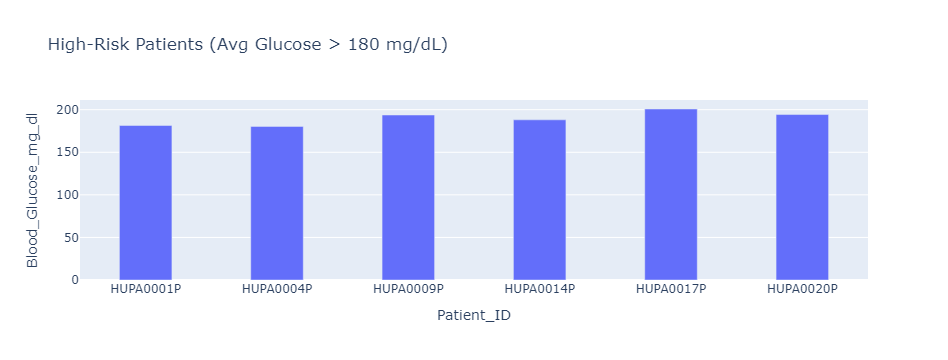

In [4]:
import plotly.express as px

# Patient-level average glucose
patient_avg = df.groupby("Patient_ID")["Blood_Glucose_mg_dl"].mean().reset_index()

# High-risk patients
high_risk = patient_avg[patient_avg["Blood_Glucose_mg_dl"] > 180]

# Bar chart with thinner bars
fig = px.bar(
    high_risk,
    x="Patient_ID",
    y="Blood_Glucose_mg_dl",
    title="High-Risk Patients (Avg Glucose > 180 mg/dL)"
)

# 🔧 Reduce bar width (increase spacing)
fig.update_layout(
    bargap=0.6  # higher value = thinner bars
)

fig.show()

### Q3: What is the relationship between carbs and glucose?
**Reasoning:**   
  Carbs turn into glucose after digestion, so eating more carbs usually raises blood glucose levels.
  Understanding this helps explain why larger or high‑carb meals cause bigger glucose spikes.
  
**Insight**   
   The correlation between carbs and glucose is –0.001, which means there is no real relationship between the two in this dataset.
   Glucose levels range widely from 50 to 400 mg/dL even when carb intake is close to 0–20 grams, showing carbs are not the main driver here.


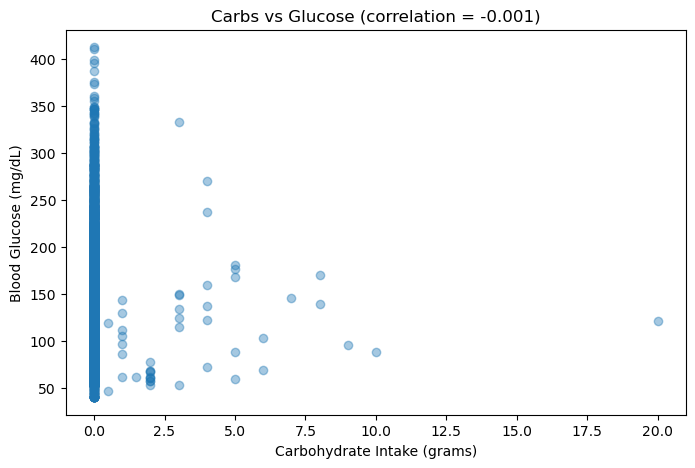

In [5]:

plot_df = df[['Carbohydrate_Intake_Grams', 'Blood_Glucose_mg_dl']].dropna()

# sample points so the plot is readable
sample_df = plot_df.sample(n=min(5000, len(plot_df)), random_state=42)

correlation = plot_df['Carbohydrate_Intake_Grams'].corr(
    plot_df['Blood_Glucose_mg_dl']
)

plt.figure(figsize=(8,5))
plt.scatter(
    sample_df['Carbohydrate_Intake_Grams'],
    sample_df['Blood_Glucose_mg_dl'],
    alpha=0.4
)

plt.xlabel("Carbohydrate Intake (grams)")
plt.ylabel("Blood Glucose (mg/dL)")
plt.title(f"Carbs vs Glucose (correlation = {correlation:.3f})")
plt.show()

### Q4: What is the average calories burned?
**Reasoning:**  
  The average is 8.81, which is relatively low. This suggests that many records in the dataset capture short time intervals with little or 
  no physical activity.
  
**Insight:**  
  this dataset contains high-frequency time-based measurements, many rows likely represent resting or low-movement periods. 
  That is why the average calories burned remains 8.81 calories, 
  even though some records may show much higher activity.


In [6]:

avg_calories = df['Calories_burned'].mean()

print("Average calories burned:", avg_calories)

Average calories burned: 8.813100209443038


### Q5: What time of day has the highest glucose variability?
**Reason:**  
  Glucose variability uses standard deviation.The highest value means glucose changed the most during that hour.
  
**Insight:**  
  At 10 PM (hour 22), glucose was most unstable (SD ≈ 64.22 mg/dL). This may be linked to evening meals, insulin effects, or 
  less activity later in the day.

In [7]:

glucose_variability = (
    df.groupby('Hour')['Blood_Glucose_mg_dl']
      .std()
)

max_hour = glucose_variability.idxmax()
max_value = glucose_variability.max()

print("Hour with highest glucose variability:", max_hour)
print("Standard deviation:", round(max_value, 2))

Hour with highest glucose variability: 22
Standard deviation: 64.22


### Q6: What percentage of glucose readings fall into hypoglycemia, normal, and hyperglycemia zones?

**Reasoning:**  
  Understanding the proportion of readings in each glucose zone helps assess overall glycemic control.
  A higher share of hyperglycemia or hypoglycemia indicates instability and potential clinical risk,
  while a larger normal‑range segment reflects better glucose management.

**Insight:**   
  Most readings fall in the Normal zone (71.5%), showing generally stable glucose control.
  However, 21.7% hyperglycemia and 6.8% hypoglycemia indicate that glucose swings still occur and need closer monitoring.

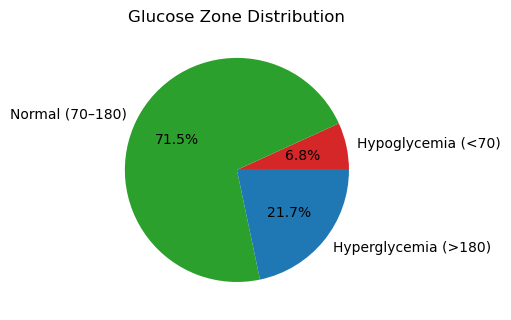

In [8]:

# Define bins and labels
bins = [-float("inf"), 70, 180, float("inf")]
labels = ["Hypoglycemia (<70)", "Normal (70–180)", "Hyperglycemia (>180)"]

# Categorize glucose values
df["Glucose_Zone"] = pd.cut(
    df["Blood_Glucose_mg_dl"],
    bins=bins,
    labels=labels,
    right=True,
    include_lowest=True
)

# Calculate percentages
zone_counts = df["Glucose_Zone"].value_counts().reindex(labels)
zone_perc = (zone_counts / zone_counts.sum()) * 100

# Pie chart
plt.figure(figsize=(5,5))
zone_perc.plot(
    kind="pie",
    autopct="%.1f%%",
    colors=["#d62728", "#2ca02c", "#1f77b4"],
    ylabel=""
)
plt.title("Glucose Zone Distribution")
plt.tight_layout()
plt.show()

### Q7: How frequently does hyperglycemia occur?
**Reasoning:**  
  Counting readings above 180 mg/dL quantifies how often the patient is at risk for acute complications. This frequency measure helps assess overall     control quality and whether interventions are reducing high-glucose events.

**Insights:**
Majority of Readings Are Normal
The dataset shows most glucose readings are below 180 mg/dL, indicating:
Overall glucose control is relatively stable for many observations.
Treatment may be effective during large portions of monitoring.
Hyperglycemia Is Still Significant
67,123 hyperglycemic readings is clinically important because:
Frequent glucose spikes increase diabetes complications risk.
Persistent hyperglycemia may indicate:
insufficient insulin response
poor meal control
stress or sleep disturbances
low activity levels

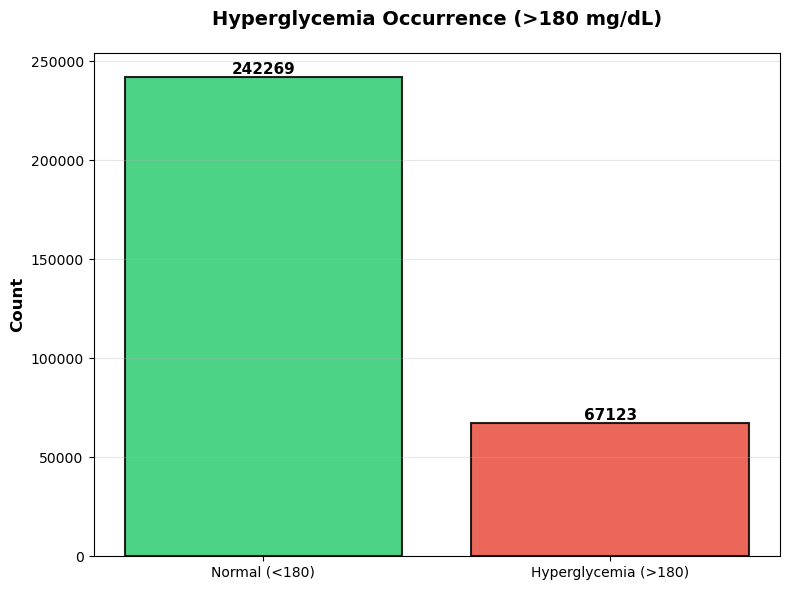

Hyperglycemia
False    242269
True      67123
Name: count, dtype: int64


In [9]:


# Create category
df['Hyperglycemia'] = df['Blood_Glucose_mg_dl'] > 180

# Count occurrences
hyper_counts = df['Hyperglycemia'].value_counts()

plt.figure(figsize=(8, 6))
colors = ['#2ecc71', '#e74c3c']
bars = plt.bar(['Normal (<180)', 'Hyperglycemia (>180)'], 
               [hyper_counts[False], hyper_counts[True]], 
               color=colors, edgecolor='black', linewidth=1.5, alpha=0.85)

plt.title("Hyperglycemia Occurrence (>180 mg/dL)", fontsize=14, fontweight='bold', pad=20)
plt.ylabel("Count", fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}', ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.tight_layout()

plt.show()

print(hyper_counts)

### Q8: Is Insulin associated with lower glucose levels?
**Reasoning:**  
   Comparing basal insulin with glucose checks whether insulin dosing is aligned with glycemic control. A clear negative relationship suggests            effective dosing, while a weak or positive trend may indicate insulin resistance, timing issues, or the need for regimen adjustment.

**Interpretation:**  
    Higher insulin should ideally correspond to lower glucose.

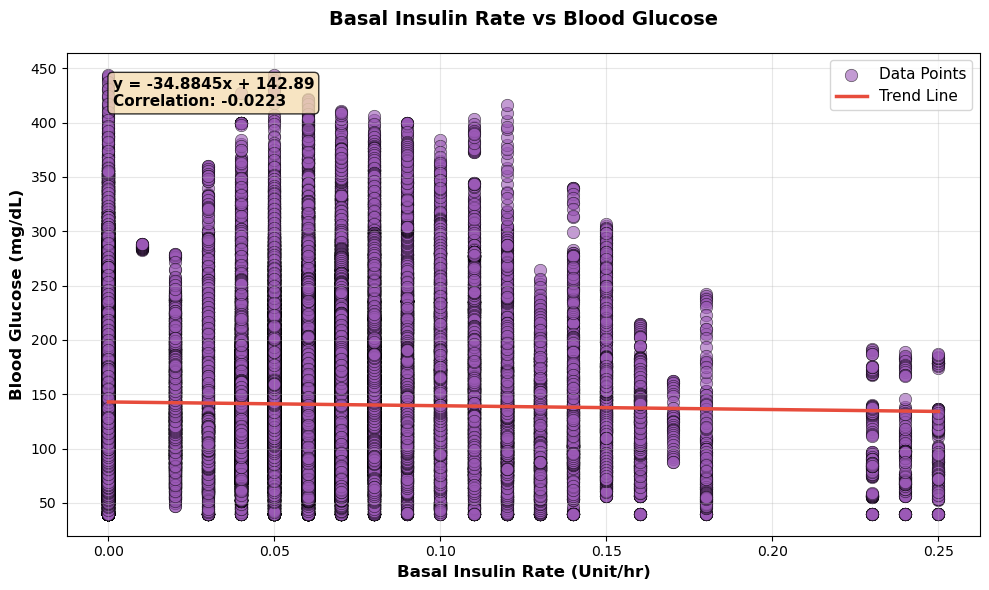

Insulin Rate vs Glucose Correlation: -0.0223
Trend Line Equation: y = -34.8845x + 142.89


In [10]:
plt.figure(figsize=(10, 6))

plt.scatter(df['Basal_Insulin_Rate_Unit_hr'], df['Blood_Glucose_mg_dl'], 
            alpha=0.6, s=80, c='#9b59b6', edgecolors='black', linewidth=0.5, label='Data Points')

# Correlation
insulin_correlation = df['Basal_Insulin_Rate_Unit_hr'].corr(df['Blood_Glucose_mg_dl'])

# Add trend line
z = np.polyfit(df['Basal_Insulin_Rate_Unit_hr'], df['Blood_Glucose_mg_dl'], 1)
p = np.poly1d(z)
x_trend = np.linspace(df['Basal_Insulin_Rate_Unit_hr'].min(), df['Basal_Insulin_Rate_Unit_hr'].max(), 100)
plt.plot(x_trend, p(x_trend), color='#e74c3c', linewidth=2.5, label='Trend Line')

# Add equation and correlation label
equation_text = f'y = {z[0]:.4f}x + {z[1]:.2f}\nCorrelation: {insulin_correlation:.4f}'
plt.text(0.05, 0.95, equation_text, transform=plt.gca().transAxes,
         fontsize=11, verticalalignment='top', bbox=dict(boxstyle='round', 
         facecolor='wheat', alpha=0.8), fontweight='bold')

plt.title("Basal Insulin Rate vs Blood Glucose", fontsize=14, fontweight='bold', pad=20)
plt.xlabel("Basal Insulin Rate (Unit/hr)", fontsize=12, fontweight='bold')
plt.ylabel("Blood Glucose (mg/dL)", fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11, loc='best')
plt.tight_layout()

plt.show()

print(f"Insulin Rate vs Glucose Correlation: {insulin_correlation:.4f}")
print(f"Trend Line Equation: y = {z[0]:.4f}x + {z[1]:.2f}")

### Q9: At which hour is glucose highest on average?
**Reasoning:**   
   This code analyzes how blood glucose levels vary throughout the day by calculating the average glucose for each hour. 
   It identifies the hour with the highest average glucose level using idxmax() and visualizes the trend with a line plot.
   The analysis helps detect peak glucose periods, which can support better meal planning, insulin timing, and diabetes management
   
**Insight:**   
   Glucose levels peak at 19:00 (7 PM) with an average of 152.56 mg/dL, indicating higher blood sugar in the evening. This suggests that evening          such as dinner intake or reduced activity may contribute to glucose spikes, which can guide dietary and insulin timing adjustments.

Hour with highest average glucose: 19
Highest average glucose level: 152.55864638444638


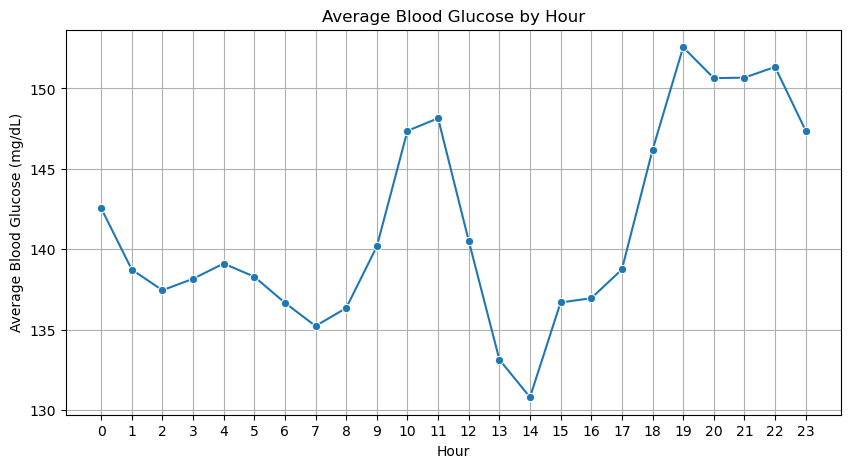

In [11]:
# Average glucose by hour
hourly_glucose = df.groupby('Hour')['Blood_Glucose_mg_dl'].mean()

# Hour with highest average glucose
highest_hour = hourly_glucose.idxmax()
highest_glucose = hourly_glucose.max()
print("Hour with highest average glucose:", highest_hour)
print("Highest average glucose level:", highest_glucose)

# Optional: visualize
plt.figure(figsize=(10,5))

sns.lineplot(
    x=hourly_glucose.index,
    y=hourly_glucose.values,
    marker='o'
)
plt.title("Average Blood Glucose by Hour")
plt.xlabel("Hour")
plt.ylabel("Average Blood Glucose (mg/dL)")
plt.xticks(range(0,24))
plt.grid(True)
plt.show()

### Q.10: What is the total step count per patient?
**Reasoning:**  
  This code calculates the total number of steps taken by each patient by summing step counts across all records. 
  It then organizes the results into a clean table and visualizes them using a bar chart to compare activity levels between patients. 
  This helps identify differences in physical activity, which can be useful for understanding its impact on blood glucose control and overall health.

**Insight:**  
  The step counts vary widely across patients, with most ranging between ~50,000 and 200,000 steps, indicating moderate to high activity levels.         However, a few patients (e.g., HUPA0026P and HUPA0027P) show extremely high totals, suggesting either exceptionally high activity or possible data     outliers that may need further validation

Patient_ID
HUPA0001P      79739.0
HUPA0002P     124830.0
HUPA0003P     103340.0
HUPA0004P      97763.0
HUPA0005P      52003.0
HUPA0006P      77879.0
HUPA0007P     177522.0
HUPA0009P     180507.0
HUPA0010P     132793.0
HUPA0011P     209547.0
HUPA0014P     136522.0
HUPA0015P     180997.0
HUPA0016P     167725.0
HUPA0017P      98989.0
HUPA0018P     135019.0
HUPA0019P     169701.0
HUPA0020P     104582.0
HUPA0021P      89402.0
HUPA0022P      80732.0
HUPA0023P      59839.0
HUPA0024P     163403.0
HUPA0025P     111473.0
HUPA0026P    1929063.0
HUPA0027P    4380913.0
HUPA0028P     492727.0
Name: Step_count, dtype: float64
   Patient_ID  Total_Step_Count
0   HUPA0001P           79739.0
1   HUPA0002P          124830.0
2   HUPA0003P          103340.0
3   HUPA0004P           97763.0
4   HUPA0005P           52003.0
5   HUPA0006P           77879.0
6   HUPA0007P          177522.0
7   HUPA0009P          180507.0
8   HUPA0010P          132793.0
9   HUPA0011P          209547.0
10  HUPA0014P          136522

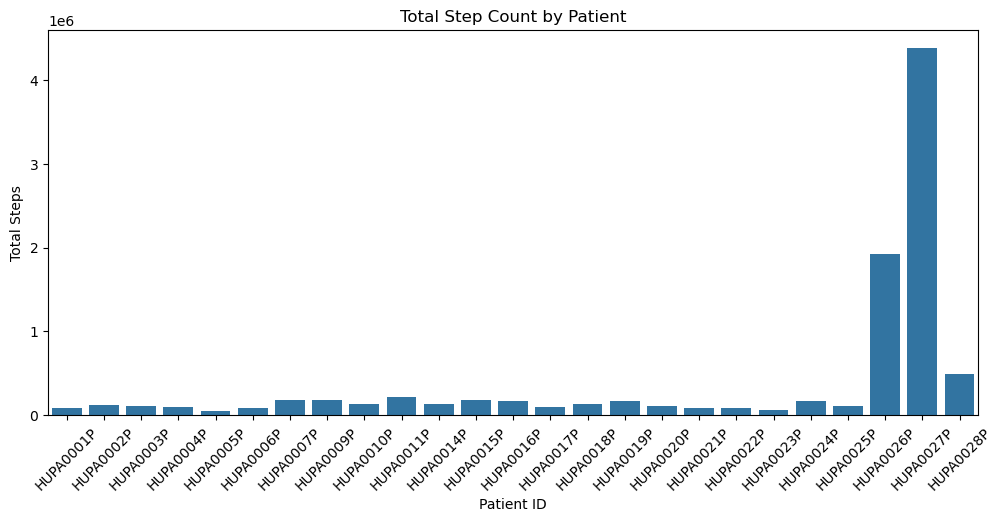

In [12]:
total_steps_by_patient = df.groupby('Patient_ID')[
    'Step_count'
].sum()

print(total_steps_by_patient)

#Convert to a clean table
total_steps_table = total_steps_by_patient.reset_index()

total_steps_table.columns = [
    'Patient_ID',
    'Total_Step_Count'
]
print(total_steps_table)

#Visualize total step count by patient
plt.figure(figsize=(12,5))

sns.barplot(
    x=total_steps_table['Patient_ID'],
    y=total_steps_table['Total_Step_Count']
)

plt.title("Total Step Count by Patient")
plt.xlabel("Patient ID")
plt.ylabel("Total Steps")

plt.xticks(rotation=45)
plt.show()


